In [1]:

!pip uninstall torch -y
!pip uninstall torchvision -y


!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install torchvision --index-url https://download.pytorch.org/whl/cu118

!pip install transformers accelerate
!pip install datasets

!pip show transformers
!pip show datasets
!pip show torch
!pip show accelerate
!pip show torchvision
!pip show torchaudio


Found existing installation: torch 2.6.0+cu124
Uninstalling torch-2.6.0+cu124:
  Successfully uninstalled torch-2.6.0+cu124
Found existing installation: torchvision 0.21.0+cu124
Uninstalling torchvision-0.21.0+cu124:
  Successfully uninstalled torchvision-0.21.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 89.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 49.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 107.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━

In [2]:
from transformers import Trainer, TrainingArguments
import pandas as pd
import json
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# connect wandb

# !pip install wandb -q

# import wandb
# wandb.login()
# wandb.init(project="PhobertDescribetion2Expert",name="Deex_o1")


In [6]:


data = []
# Thay đổi đường dẫn này cho phù hợp với vị trí tệp của bạn trên Google Drive
file_path = '/content/drive/My Drive/crawl_data/data.json'
with open(file_path, 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
print(df.head())

                                     mo_ta_cong_viec  \
0  Tham gia sản xuất chi tiết về về hình ảnh cho ...   
1  Phân tích nghiệp vụ:\nKhai thác yêu cầu sản ph...   
2  Product Development and Management:\n- Define ...   
3  Thiết kế các ấn phẩm truyền thông số như hình ...   
4  Đảm nhận công việc thiết kế đồ họa truyền hình...   

                               chuyen_mon  
0        Thiết kế đồ họa (Graphic Design)  
1  Business Analyst (Phân tích nghiệp vụ)  
2           Product Owner/Product Manager  
3        Thiết kế đồ họa (Graphic Design)  
4        Thiết kế đồ họa (Graphic Design)  


In [7]:
labels = [
        "Software Engineer", "Backend Developer", "Fullstack Developer", "Mobile Developer",
        "Frontend Developer", "Blockchain Engineer", "Kinh doanh phần mềm", "Sales IT Phần mềm khác",
        "Kinh doanh Domain/Hosting/Server", "Thiết kế đồ họa (Graphic Design)", "Animation Design",
        "3D Molder",  "Illustration", "IT Helpdesk/IT support",
        "DevOps Engineer", "Kỹ thuật IT", "System Administrator", "Network Engineer", "System Engineer",
        "Database Administrator (DBA)", "Cloud Engineer", "Software Tester (Automation & Manual)",
        "Manual Tester", "Automation Tester", "QA Engineer", "Process Quality Assurance (PQA)",
        "Game Tester", "Business Analyst (Phân tích nghiệp vụ)", "Product Owner/Product Manager",
        "Product Analyst/Research", "Thiết kế đồ họa (Graphic Design)", "UI/UX Design",
        "3D Molder",  "IT Consultant",
        "Bán hàng kỹ thuật IT", "BIM Engineer", "IT Project Manager", "Kỹ sư cầu nối BrSE",
        "IT Comtor", "Scrum Master", "Data Analyst", "Data Engineer", "Data Scientist"
    ]
print("so luong label: ",len(labels))



so luong label:  43


In [8]:
# Loại bỏ các dòng có nhãn không hợp lệ
df = df[df['chuyen_mon'].isin(labels)]

# Tạo ánh xạ nhãn sang ID
label_map = {label: i for i, label in enumerate(labels)}
df['label'] = df['chuyen_mon'].map(label_map)

# Chuẩn bị dữ liệu cho huấn luyện
texts = df['mo_ta_cong_viec'].tolist()
label_ids = df['label'].tolist()

<ipython-input-8-9638145b87cf>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['label'] = df['chuyen_mon'].map(label_map)


Số lượng mẫu cho mỗi nhãn:
chuyen_mon
Thiết kế đồ họa (Graphic Design)          502
Kinh doanh phần mềm                       253
Software Engineer                         205
Backend Developer                         203
Business Analyst (Phân tích nghiệp vụ)    138
Fullstack Developer                       101
Mobile Developer                           99
Software Tester (Automation & Manual)      82
Frontend Developer                         80
Manual Tester                              71
UI/UX Design                               65
DevOps Engineer                            61
IT Helpdesk/IT support                     61
IT Project Manager                         59
Product Owner/Product Manager              57
Kỹ thuật IT                                56
Data Analyst                               44
System Administrator                       38
System Engineer                            35
Sales IT Phần mềm khác                     32
Data Engineer                             

<ipython-input-9-6217f9805cca>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='chuyen_mon', data=df, order=label_counts.index, palette='viridis')


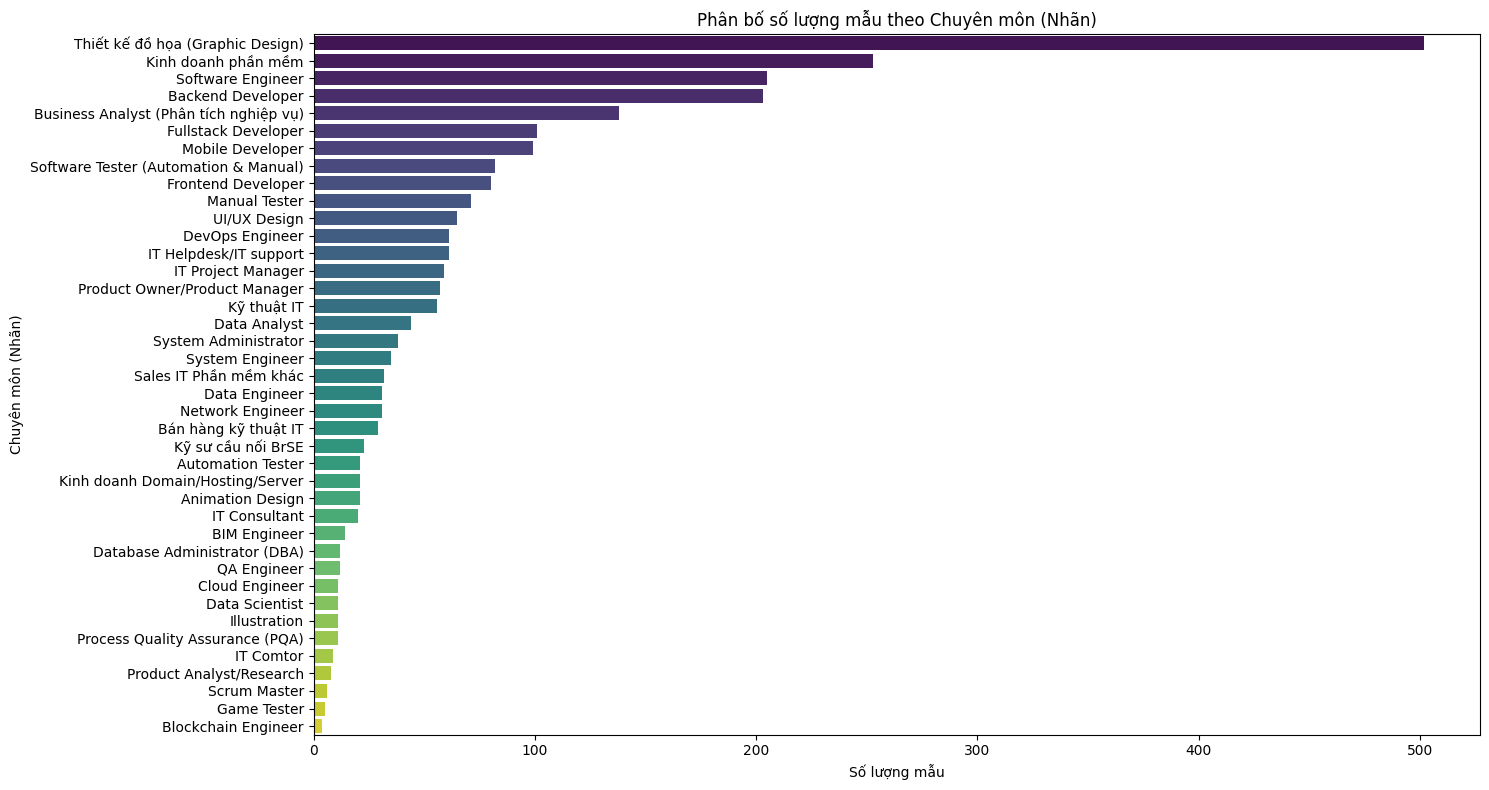

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
# Lọc dữ liệu theo danh sách nhãn đã định nghĩa
df = df[df['chuyen_mon'].isin(labels)]

# 1. Kiểm tra phân bố nhãn
label_counts = df['chuyen_mon'].value_counts()
print("Số lượng mẫu cho mỗi nhãn:")
print(label_counts)

# 2. Tính toán tỷ lệ
label_percentages = df['chuyen_mon'].value_counts(normalize=True) * 100
print("\nTỷ lệ phần trăm mẫu cho mỗi nhãn:")
print(label_percentages)

# 3. Trực quan hóa phân bố nhãn
plt.figure(figsize=(15, 8))
sns.countplot(y='chuyen_mon', data=df, order=label_counts.index, palette='viridis')
plt.title('Phân bố số lượng mẫu theo Chuyên môn (Nhãn)')
plt.xlabel('Số lượng mẫu')
plt.ylabel('Chuyên môn (Nhãn)')
plt.tight_layout()
plt.show()

In [10]:


train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, label_ids, test_size=0.2, random_state=42, stratify=label_ids
)
#check train_texts 100 record
for i in range(100):
    print("description :",train_texts[i])
    print("expert :",labels[train_labels[i]])

description : Building and developing mobile apps for customer and company products.
Contribute, develop products from the design phase, project initialization
Collaborate with other departments such as BA, tester to develop products
Design, develop and optimize the performance of Mobile Apps products on Flutter/ React Native/ Android Native/ iOS Native platforms
Explore and refer to new technologies to consistently innovate and upgrade products.
Perform other duties as assigned by the Direct Manager.
expert : Mobile Developer
description : - Gọi điện tư vấn khách hàng theo data công ty
- Hướng dẫn và giới thiệu khách hàng tìm hiểu Website và tư vấn Website thương hiệu hỗ trợ kinh doanh Online - Chuyển đổi công nghệ số
- Phát triển khách hàng đang có và mở rộng mô hình chiến lược kinh doanh cho khách hàng
- Xử lý các yêu cầu hỗ trợ của khách hàng
- Được hướng dẫn và đào tạo trực tiếp khi làm việc.
expert : Kinh doanh phần mềm
description : Tìm kiếm và phát triển khách hàng tiềm năng.
T

In [11]:

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
model = AutoModelForSequenceClassification.from_pretrained("vinai/phobert-base", num_labels=len(labels))
# Kiểm tra và chuyển mô hình sang GPU nếu có
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(64001, 768, padding_idx=1)
      (position_embeddings): Embedding(258, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [12]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=256)

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

In [13]:


class JobDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)
train_dataset = JobDataset(train_encodings, train_labels)
val_dataset = JobDataset(val_encodings, val_labels)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)


In [14]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    f1=f1_score(labels, preds, average='weighted')
    acc=accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1': f1}

In [19]:
# when start train model, please leave comment

# training_args = TrainingArguments(
#     output_dir='./content/drive/My Drive/phobert_job_classification_model',
#     num_train_epochs=100,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     warmup_steps=500,
#     weight_decay=0.01,
#     logging_dir='./logs',
#     logging_steps=10,
#     # evaluation_strategy="epoch",
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     load_best_model_at_end=True,
#     metric_for_best_model="eval_loss",
#     report_to="wandb"
# )
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     compute_metrics=compute_metrics,
# )
# trainer.train()

In [20]:
# close wandb

# results = trainer.evaluate(val_dataset)
# print(results)

# wandb.finish()

In [18]:
# test

output_dir = '/content/drive/My Drive/phobert_job_classification_model/checkpoint-5504'
model = AutoModelForSequenceClassification.from_pretrained(output_dir)
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


test_texts = [
    '''Giới thiệu các giải pháp về phần mềm tích hợp như API Management, MQ, Event Streaming, ESB… với khách hàng chủ yếu trong lĩnh vực Tài chính, Ngân hàng.
Phối hợp cùng các bạn kỹ sư Amigo, hãng, đối tác thực hiện demo, PoC tính năng sản phẩm, làm thầu, triển khai các dự án về giải pháp phần mềm tích hợp.
Nghiên cứu các giải pháp, công nghệ theo định hướng của công ty.
Các công việc khác theo yêu cầu''',
    '''- Lập trình và phát triển app di động bằng ngôn ngữ Kotlin ưu tiên biết thêm React Native, đã từng làm Google Admob.
Tham gia xây dựng, nâng cấp và sửa lỗi cho các ứng dụng đã có.
Phối hợp với team thiết kế, backend và tester để hoàn thiện sản phẩm.''',
    '''Lên ý tưởng, thiết kế các hạng mục sản phẩm quảng cáo theo yêu cầu: catalogue, thiết kế sân khấu, backdrop, banner,...
Hỗ trợ các bộ phận khác các vấn đề liên quan đến chuyên môn.
Đảm bảo chất lượng hình ảnh và thời gian hoàn thành đúng deadline.
Cập nhật xu hướng thiết kế mới, ứng dụng vào công việc.'''

]


test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=256, return_tensors="pt")


test_encodings = {key: tensor.to(device) for key, tensor in test_encodings.items()}


with torch.no_grad():
    outputs = model(**test_encodings)


probabilities = torch.softmax(outputs.logits, dim=1)


predicted_label_indices = torch.argmax(probabilities, dim=1)


id_to_label = {i: label for label, i in label_map.items()}
predicted_labels = [id_to_label[idx.item()] for idx in predicted_label_indices]


for text, label in zip(test_texts, predicted_labels):
    print(f"desribetion: '{text}'")
    print(f"Predicted label: {label}\n")

desribetion: 'Giới thiệu các giải pháp về phần mềm tích hợp như API Management, MQ, Event Streaming, ESB… với khách hàng chủ yếu trong lĩnh vực Tài chính, Ngân hàng.
Phối hợp cùng các bạn kỹ sư Amigo, hãng, đối tác thực hiện demo, PoC tính năng sản phẩm, làm thầu, triển khai các dự án về giải pháp phần mềm tích hợp.
Nghiên cứu các giải pháp, công nghệ theo định hướng của công ty.
Các công việc khác theo yêu cầu'
Predicted label: Backend Developer

desribetion: '- Lập trình và phát triển app di động bằng ngôn ngữ Kotlin ưu tiên biết thêm React Native, đã từng làm Google Admob.
Tham gia xây dựng, nâng cấp và sửa lỗi cho các ứng dụng đã có.
Phối hợp với team thiết kế, backend và tester để hoàn thiện sản phẩm.'
Predicted label: Mobile Developer

desribetion: 'Lên ý tưởng, thiết kế các hạng mục sản phẩm quảng cáo theo yêu cầu: catalogue, thiết kế sân khấu, backdrop, banner,...
Hỗ trợ các bộ phận khác các vấn đề liên quan đến chuyên môn.
Đảm bảo chất lượng hình ảnh và thời gian hoàn thành đú